In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\atchi\\Downloads\\StudentsPerformance.csv")
df.head()
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
(1000, 8)


In [3]:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [5]:
print("Duplicate Rows", df.duplicated().sum())

Duplicate Rows 0


In [6]:
df = df.drop_duplicates()

In [10]:
print(df.dtypes)

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [14]:
df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"])/3

In [15]:
def performance(avg):
    if avg >= 80:
        return "Excellent"
    elif avg >= 60:
        return "Good"
    else:
        return "Need Improvement"
df["performance"] = df["average_score"].apply(performance)

In [16]:
print(df.describe())

       math score  reading score  writing score  average_score
count  1000.00000    1000.000000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000      67.770667
std      15.16308      14.600192      15.195657      14.257326
min       0.00000      17.000000      10.000000       9.000000
25%      57.00000      59.000000      57.750000      58.333333
50%      66.00000      70.000000      69.000000      68.333333
75%      77.00000      79.000000      79.000000      77.666667
max     100.00000     100.000000     100.000000     100.000000


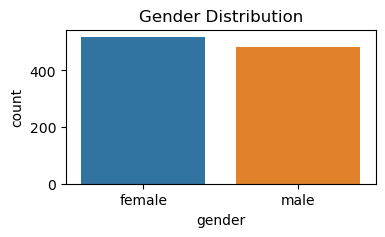

In [21]:
plt.figure(figsize=(4,2))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

C:\Users\atchi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


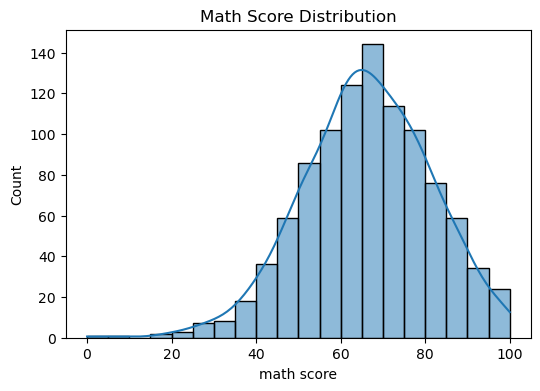

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df["math score"], bins=20, kde= True)
plt.title("Math Score Distribution")
plt.show()

C:\Users\atchi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


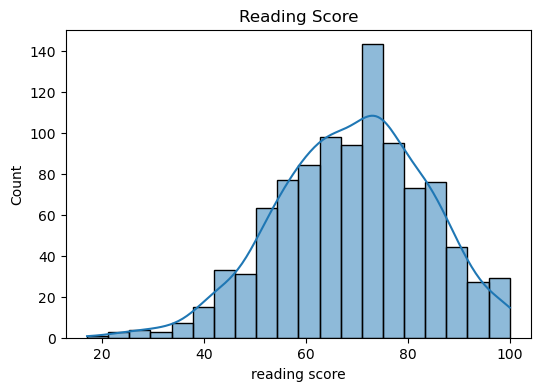

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df["reading score"], bins=20, kde=True)
plt.title("Reading Score")
plt.show()

C:\Users\atchi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


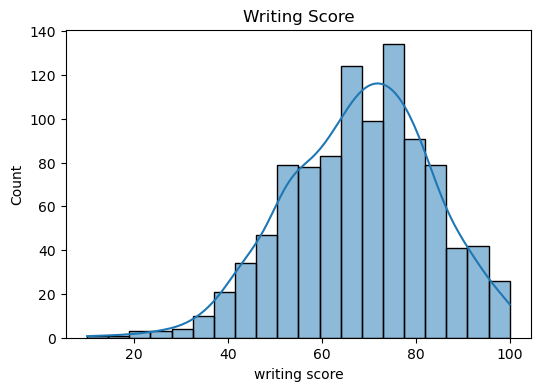

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df["writing score"], bins=20, kde=True)
plt.title("Writing Score")
plt.show()

In [30]:
gender_score = df.groupby("gender")[["math score", "reading score", "writing score"]].mean()
print(gender_score)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


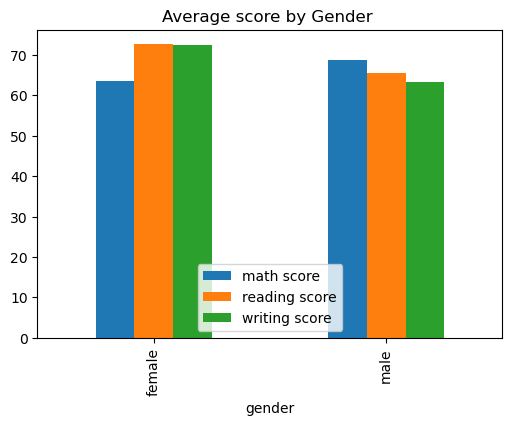

In [32]:
gender_score.plot(kind="bar", figsize=(6,4))
plt.title("Average score by Gender ")
plt.show()

In [35]:
prep_score =df.groupby("test preparation course")[[ "math score", "reading score", "writing score"]].mean()
print(prep_score)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


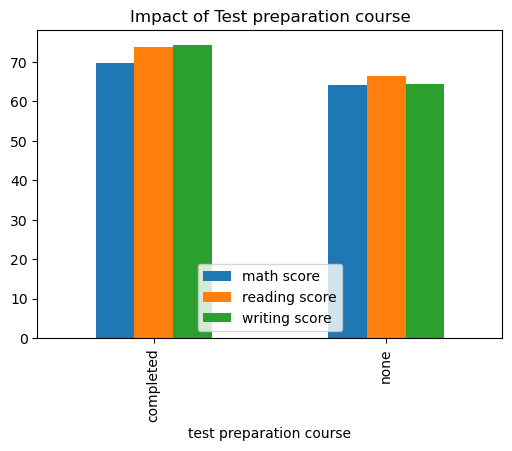

In [65]:
prep_score.plot(kind="bar", figsize=(6,4))
plt.title("Impact of Test preparation course")
plt.show()

In [40]:
lunch_score = df.groupby("lunch")[["math score", "reading score","writing score"]].mean()
print(lunch_score)

              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


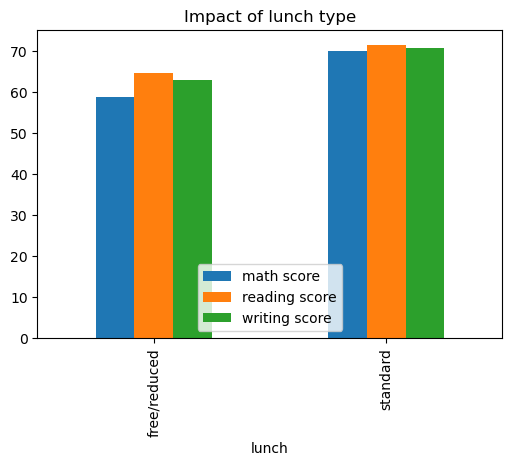

In [67]:
lunch_score.plot(kind="bar", figsize=(6,4))
plt.title("Impact of lunch type")
plt.show()

In [43]:
parent_score = df.groupby("parental level of education")["average_score"].mean().sort_values()
print(parent_score)

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64


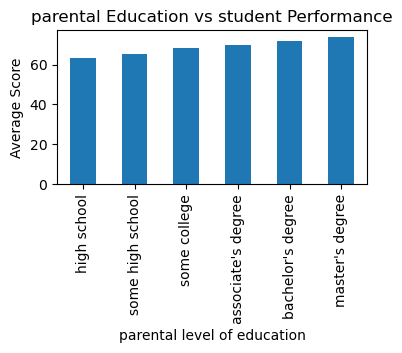

In [46]:
plt.figure(figsize=(4,2))
parent_score.plot(kind="bar")
plt.title("parental Education vs student Performance")
plt.ylabel("Average Score")
plt.show()

In [48]:
corr = df[["math score","reading score","writing score","average_score"]].corr()
print(corr)

               math score  reading score  writing score  average_score
math score       1.000000       0.817580       0.802642       0.918746
reading score    0.817580       1.000000       0.954598       0.970331
writing score    0.802642       0.954598       1.000000       0.965667
average_score    0.918746       0.970331       0.965667       1.000000


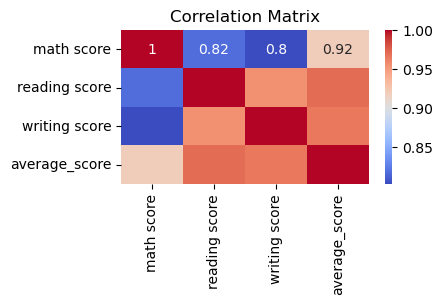

In [49]:
plt.figure(figsize=(4,2))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [52]:
print(df["average_score"].std())
print(df["average_score"].var())

14.257325984669153
203.27134423312222


In [51]:
print(df["average_score"].mean())
print(df["average_score"].median())

67.77066666666666
68.33333333333333


In [55]:
top_students = df.sort_values(by ="average_score", ascending = False)
print(top_students.head(10))

     gender race/ethnicity parental level of education         lunch  \
916    male        group E           bachelor's degree      standard   
458  female        group E           bachelor's degree      standard   
962  female        group E          associate's degree      standard   
114  female        group E           bachelor's degree      standard   
179  female        group D            some high school      standard   
712  female        group D                some college      standard   
165  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
903  female        group D           bachelor's degree  free/reduced   
149    male        group E          associate's degree  free/reduced   

    test preparation course  math score  reading score  writing score  \
916               completed         100            100            100   
458                    none         100            100       

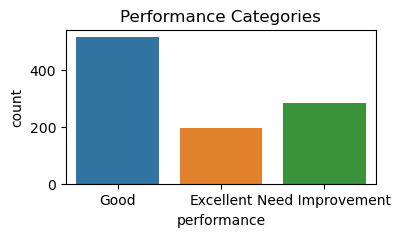

In [60]:
plt.figure(figsize=(4,2))
sns.countplot(x="performance", data =df)
plt.title("Performance Categories")
plt.show()

In [64]:
df.to_csv("cleaned_students_performance.csv", index=False)